Nombre: Emilio Rico Hernández
Tarea: Jueves 6 de Agosto
Tema: Método de Montecarlo
Fecha: 2026-09-25

# Tarea Jueves 6 de Agosto
## Ejercicios prácticos: Método de Montecarlo en Python

El método de Montecarlo usa números aleatorios para aproximar resultados que serían difíciles de calcular de forma exacta. La idea es simple: se simula el mismo experimento muchas veces y con el promedio (o la proporción) de los resultados se estima lo que buscamos. Aquí resuelvo los tres ejercicios de la tarea: uno básico, uno medio y uno avanzado.

En los tres casos fijo una semilla (`seed`) para que los resultados se puedan reproducir al volver a correr el notebook, y comparo contra el valor exacto para ver qué tan buena es la aproximación.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# generador de números aleatorios con semilla fija para que salga siempre igual
rng = np.random.default_rng(42)

## 1. Nivel básico: estimación de π

**Problema:** aproximar π simulando dardos aleatorios sobre un cuadrado de lado 2 que contiene un círculo de radio 1.

**Fundamento:** el área del círculo es $A_c = \pi r^2 = \pi$ y el área del cuadrado es $A_q = (2r)^2 = 4$. Si el punto $(x, y)$ es uniforme en el cuadrado, la probabilidad de caer dentro del círculo es la proporción de las áreas:

$$P(x^2 + y^2 \le 1) = \frac{\text{Área del círculo}}{\text{Área del cuadrado}} = \frac{\pi}{4}$$

Entonces: $\pi \approx 4 \cdot \dfrac{\text{puntos dentro del círculo}}{\text{puntos totales}}$.

In [2]:
def estimar_pi(n_puntos):
    """Lanza n_puntos dardos en [-1, 1] x [-1, 1] y estima pi."""
    # x e y uniformes entre -1 y 1
    x = rng.uniform(-1, 1, n_puntos)
    y = rng.uniform(-1, 1, n_puntos)

    # un punto está dentro del círculo si su distancia al origen es <= 1
    dentro = (x**2 + y**2) <= 1

    # proporción de aciertos multiplicada por 4
    return 4 * dentro.mean()


n = 100_000
pi_estimado = estimar_pi(n)

print(f"Puntos simulados: {n}")
print(f"pi estimado:      {pi_estimado}")
print(f"pi real:          {math.pi}")
print(f"Error absoluto:   {abs(pi_estimado - math.pi):.5f}")

Puntos simulados: 100000
pi estimado:      3.14308
pi real:          3.141592653589793
Error absoluto:   0.00149


Para ver el método "en acción" grafico solo 2,000 puntos (con 100,000 no se distinguirían): los azules cayeron dentro del círculo y los rojos fuera.

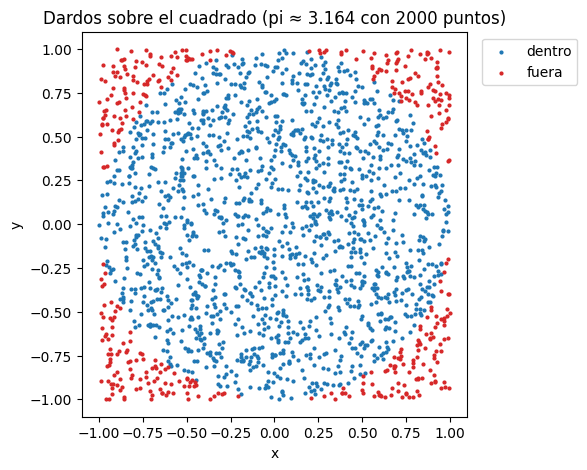

In [3]:
n_graf = 2000
x = rng.uniform(-1, 1, n_graf)
y = rng.uniform(-1, 1, n_graf)
dentro = (x**2 + y**2) <= 1

plt.figure(figsize=(5, 5))
plt.scatter(x[dentro], y[dentro], s=4, color="tab:blue", label="dentro")
plt.scatter(x[~dentro], y[~dentro], s=4, color="tab:red", label="fuera")
plt.title(f"Dardos sobre el cuadrado (pi ≈ {4 * dentro.mean():.3f} con {n_graf} puntos)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.gca().set_aspect("equal")
plt.show()

Ahora reviso qué pasa cuando aumenta el número de puntos. Repito la estimación 10 veces con cada tamaño de muestra y saco el error promedio.

In [4]:
print(f"{'N':>10} | {'pi estimado (1 corrida)':>24} | {'error promedio (10 corridas)':>28}")
print("-" * 70)
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    estimaciones = [estimar_pi(n) for _ in range(10)]
    error_prom = np.mean([abs(e - math.pi) for e in estimaciones])
    print(f"{n:>10} | {estimaciones[0]:>24.5f} | {error_prom:>28.5f}")

         N |  pi estimado (1 corrida) | error promedio (10 corridas)
----------------------------------------------------------------------
       100 |                  3.12000 |                      0.14800
      1000 |                  3.22400 |                      0.04664
     10000 |                  3.08840 |                      0.01436
    100000 |                  3.14628 |                      0.00465
   1000000 |                  3.13966 |                      0.00122


**Interpretación:** con 100,000 puntos la estimación queda muy cerca de π (error de milésimas). Al aumentar N el error baja, pero lento: para reducirlo a la mitad hay que usar aproximadamente 4 veces más puntos, porque el error de Montecarlo disminuye con $1/\sqrt{N}$. Por eso el método no es el más eficiente para calcular π, pero sirve para ver que funciona.

## 2. Nivel medio: integración numérica

**Problema:** calcular con Montecarlo la integral definida de $f(x) = e^{-x^2}$ en el intervalo $[0, 2]$.

**Fundamento:** si $X_i \sim U(a, b)$, la integral se aproxima con

$$\int_a^b f(x)\,dx \approx \frac{b-a}{N}\sum_{i=1}^{N} f(x_i)$$

o sea, el promedio de la función en puntos aleatorios multiplicado por el ancho del intervalo.

In [5]:
def f(x):
    # función a integrar: e^(-x^2)
    return np.exp(-x**2)


def integrar_montecarlo(funcion, a, b, n_puntos):
    """Estima la integral de funcion en [a, b] y su error estándar."""
    x = rng.uniform(a, b, n_puntos)          # puntos aleatorios en [a, b]
    valores = funcion(x)                      # f evaluada en cada punto

    integral = (b - a) * valores.mean()       # (b - a) * promedio
    error_est = (b - a) * valores.std(ddof=1) / np.sqrt(n_puntos)
    return integral, error_est


a, b = 0, 2
n = 100_000
integral_mc, error_est = integrar_montecarlo(f, a, b, n)

# valor exacto: la integral de e^(-x^2) de 0 a 2 es (sqrt(pi)/2) * erf(2)
exacto = math.sqrt(math.pi) / 2 * math.erf(2)

print(f"Puntos simulados:        {n}")
print(f"Integral estimada:       {integral_mc:.5f}")
print(f"Error estándar:          {error_est:.5f}")
print(f"Intervalo al 95%:        [{integral_mc - 1.96*error_est:.5f}, {integral_mc + 1.96*error_est:.5f}]")
print(f"Valor exacto (con erf):  {exacto:.5f}")

Puntos simulados:        100000
Integral estimada:       0.88038
Error estándar:          0.00218
Intervalo al 95%:        [0.87611, 0.88464]
Valor exacto (con erf):  0.88208


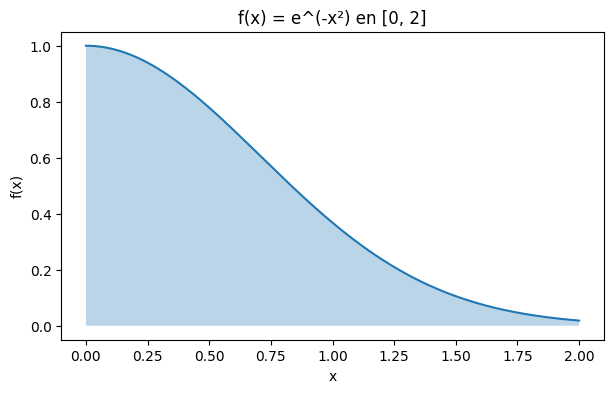

In [6]:
# grafica de la funcion y del area que estamos integrando
xs = np.linspace(0, 2, 200)
plt.figure(figsize=(7, 4))
plt.plot(xs, f(xs), color="tab:blue")
plt.fill_between(xs, f(xs), alpha=0.3)
plt.title("f(x) = e^(-x²) en [0, 2]")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

In [7]:
print(f"{'N':>10} | {'integral estimada':>18} | {'error absoluto':>15}")
print("-" * 52)
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    est, _ = integrar_montecarlo(f, 0, 2, n)
    print(f"{n:>10} | {est:>18.5f} | {abs(est - exacto):>15.5f}")

         N |  integral estimada |  error absoluto
----------------------------------------------------
       100 |            0.89698 |         0.01490
      1000 |            0.86598 |         0.01610
     10000 |            0.88963 |         0.00755
    100000 |            0.88216 |         0.00008
   1000000 |            0.88262 |         0.00054


**Interpretación:** el valor estimado ronda 0.88, y el valor exacto (que se puede obtener con la función error `erf`) está dentro del intervalo de confianza al 95%. Al igual que con π, más puntos mejoran la estimación, aunque no de forma perfectamente monótona: como hay azar, una corrida con menos puntos a veces sale más cerca que otra con más. Lo importante es la tendencia.

## 3. Nivel avanzado: valuación de opciones financieras

**Problema:** estimar el precio de una opción de compra europea (*European Call*) simulando el precio de una acción con movimiento browniano geométrico.

**Fundamento:** bajo Black-Scholes, el precio de la acción al vencimiento $T$ es

$$S_T = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\,Z\right), \qquad Z \sim \mathcal{N}(0, 1)$$

y el precio de la opción es el valor presente del pago esperado:

$$C = e^{-rT}\,\mathbb{E}[\max(S_T - K, 0)]$$

Donde:
- $S_0$: precio inicial de la acción
- $K$: precio de ejercicio (strike)
- $r$: tasa libre de riesgo
- $\sigma$: volatilidad
- $T$: tiempo al vencimiento, en años

In [8]:
def precio_call_mc(S0, K, r, sigma, T, n_sim):
    """Precio de una call europea por Montecarlo (devuelve precio y error estándar)."""
    z = rng.standard_normal(n_sim)                                      # Z ~ N(0, 1)
    ST = S0 * np.exp((r - sigma**2 / 2) * T + sigma * np.sqrt(T) * z)   # ecuación (3)
    pago = np.maximum(ST - K, 0)                                        # max(ST - K, 0)

    descuento = np.exp(-r * T)                                          # e^(-rT)
    precio = descuento * pago.mean()                                    # ecuación (4)
    error_est = descuento * pago.std(ddof=1) / np.sqrt(n_sim)
    return precio, error_est, ST


# parámetros de ejemplo
S0 = 100       # precio inicial
K = 105        # strike
r = 0.05       # tasa libre de riesgo (5% anual)
sigma = 0.20   # volatilidad (20% anual)
T = 1          # 1 año
n = 100_000

precio, error_est, ST = precio_call_mc(S0, K, r, sigma, T, n)

print(f"Simulaciones:              {n}")
print(f"Precio estimado de la call: {precio:.4f}")
print(f"Error estándar:             {error_est:.4f}")
print(f"Intervalo al 95%:           [{precio - 1.96*error_est:.4f}, {precio + 1.96*error_est:.4f}]")

Simulaciones:              100000
Precio estimado de la call: 8.0071
Error estándar:             0.0417
Intervalo al 95%:           [7.9253, 8.0889]


Para saber si el resultado es razonable lo comparo con la fórmula cerrada de Black-Scholes, que para una call europea sí tiene solución exacta:

$$C = S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2), \quad d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [9]:
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (math.log(S0 / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)


bs = black_scholes_call(S0, K, r, sigma, T)
print(f"Precio Black-Scholes (fórmula exacta): {bs:.4f}")
print(f"Precio Montecarlo:                     {precio:.4f}")
print(f"Diferencia:                            {abs(precio - bs):.4f}")

Precio Black-Scholes (fórmula exacta): 8.0214
Precio Montecarlo:                     8.0071
Diferencia:                            0.0142


Proporción de simulaciones donde la opción termina 'en el dinero' (S_T > K): 46.21%


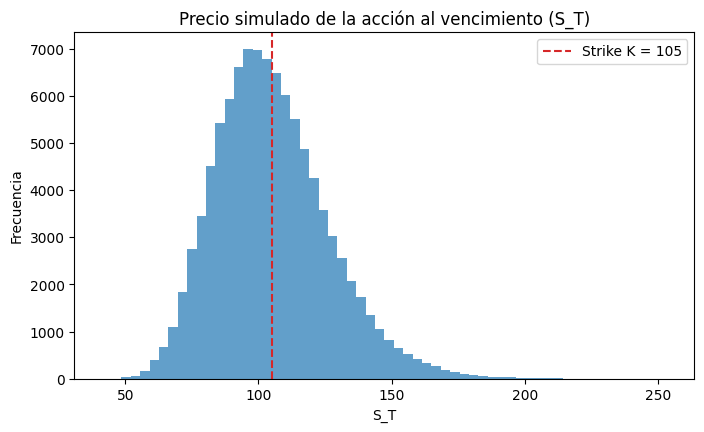

In [10]:
# distribución de los precios simulados al vencimiento
plt.figure(figsize=(8, 4.5))
plt.hist(ST, bins=60, color="tab:blue", alpha=0.7)
plt.axvline(K, color="tab:red", linestyle="--", label=f"Strike K = {K}")
plt.title("Precio simulado de la acción al vencimiento (S_T)")
plt.xlabel("S_T")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

prob_ejercer = (ST > K).mean()
print(f"Proporción de simulaciones donde la opción termina 'en el dinero' (S_T > K): {prob_ejercer:.2%}")

In [11]:
print(f"{'simulaciones':>13} | {'precio MC':>10} | {'error abs vs BS':>16}")
print("-" * 48)
for n_sim in [100, 1_000, 10_000, 100_000, 1_000_000]:
    p, _, _ = precio_call_mc(S0, K, r, sigma, T, n_sim)
    print(f"{n_sim:>13} | {p:>10.4f} | {abs(p - bs):>16.4f}")

 simulaciones |  precio MC |  error abs vs BS
------------------------------------------------
          100 |     7.5445 |           0.4768
         1000 |     7.6047 |           0.4167
        10000 |     8.2441 |           0.2227
       100000 |     8.0165 |           0.0049
      1000000 |     8.0417 |           0.0203


**Interpretación:** el precio de la call queda alrededor de 8 (con estos parámetros), muy cerca del valor de Black-Scholes, y este último cae dentro del intervalo al 95% que sacamos. En un poco menos de la mitad de las simulaciones (46%, según la celda anterior) el precio final supera al strike; en el resto la opción vale cero, pero cuando sí se ejerce el pago puede ser grande. El promedio de todos esos pagos, descontado a valor presente, es el precio de la opción. Con pocas simulaciones el estimado se mueve bastante (con 100 quedó casi medio punto abajo) y con cientos de miles ya queda a unos cuantos centésimos del valor exacto.

## Conclusión general

Los tres ejercicios siguen la misma receta: (1) generar muchos valores aleatorios, (2) evaluar lo que nos interesa en cada uno y (3) promediar. Con π fue una proporción de puntos, con la integral fue el promedio de la función por el ancho del intervalo, y con la opción fue el promedio de los pagos descontados. En los tres casos pude comprobar el resultado contra un valor exacto, y el error baja al usar más simulaciones, aunque despacio (orden $1/\sqrt{N}$). La ventaja de Montecarlo es que sirve incluso cuando no existe una fórmula cerrada, como pasa con opciones más complejas.